# 01 — Análisis exploratorio de datos (EDA)

**Taller MLOps UNI** — Predicción de resistencia del concreto

En este notebook exploraremos el dataset de resistencia a la compresión del concreto
para entender su estructura, distribuciones y relaciones entre variables.

---

## 1. Configuración inicial

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. Carga del dataset

In [3]:
# Ruta al dataset crudo
DATA_PATH = "../data/raw/concrete_data.csv"

# Si estás en Google Colab, sube el CSV o usa esta ruta:
# DATA_PATH = "concrete_data.csv"

df = pd.read_csv(DATA_PATH)

# Limpiar nombres de columnas (algunos tienen espacios extra)
df.columns = df.columns.str.strip()

print(f"Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Dataset cargado: 1030 filas x 9 columnas


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


## 3. Información general del dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   cement                         1030 non-null   float64
 1   blast_furnace_slag             1030 non-null   float64
 2   fly_ash                        1030 non-null   float64
 3   water                          1030 non-null   float64
 4   superplasticizer               1030 non-null   float64
 5   coarse_aggregate               1030 non-null   float64
 6   fine_aggregate                 1030 non-null   float64
 7   age                            1030 non-null   int64  
 8   concrete_compressive_strength  1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [5]:
# Estadísticas descriptivas
df.describe().round(2)

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
count,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00
mean,281.17,73.90,54.19,181.57,6.20,972.92,773.58,45.66,35.82
std,104.51,86.28,64.00,21.35,5.97,77.75,80.18,63.17,16.71
min,102.00,0.00,0.00,121.80,0.00,801.00,594.00,1.00,2.33
25%,192.38,0.00,0.00,164.90,0.00,932.00,730.95,7.00,23.71
50%,272.90,22.00,0.00,185.00,6.40,968.00,779.50,28.00,34.44
75%,350.00,142.95,118.30,192.00,10.20,1029.40,824.00,56.00,46.14
max,540.00,359.40,200.10,247.00,32.20,1145.00,992.60,365.00,82.60


In [6]:
# Verificar valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())
print(f"\nTotal de valores nulos: {df.isnull().sum().sum()}")

Valores nulos por columna:
cement                           0
blast_furnace_slag               0
fly_ash                          0
water                            0
superplasticizer                 0
coarse_aggregate                 0
fine_aggregate                   0
age                              0
concrete_compressive_strength    0
dtype: int64

Total de valores nulos: 0


In [7]:
# Verificar duplicados
duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {duplicados}")

Filas duplicadas: 25


## 4. Distribución de la variable objetivo

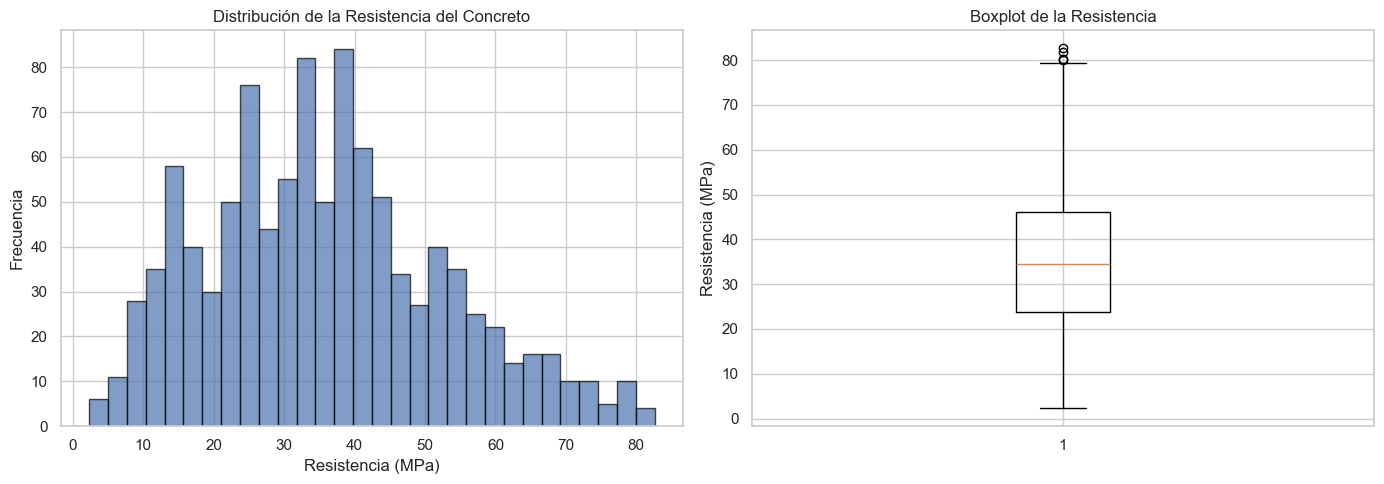

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df["concrete_compressive_strength"], bins=30, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Resistencia (MPa)")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución de la Resistencia del Concreto")

# Boxplot
axes[1].boxplot(df["concrete_compressive_strength"], vert=True)
axes[1].set_ylabel("Resistencia (MPa)")
axes[1].set_title("Boxplot de la Resistencia")

plt.tight_layout()
plt.show()

## 5. Distribución de las features

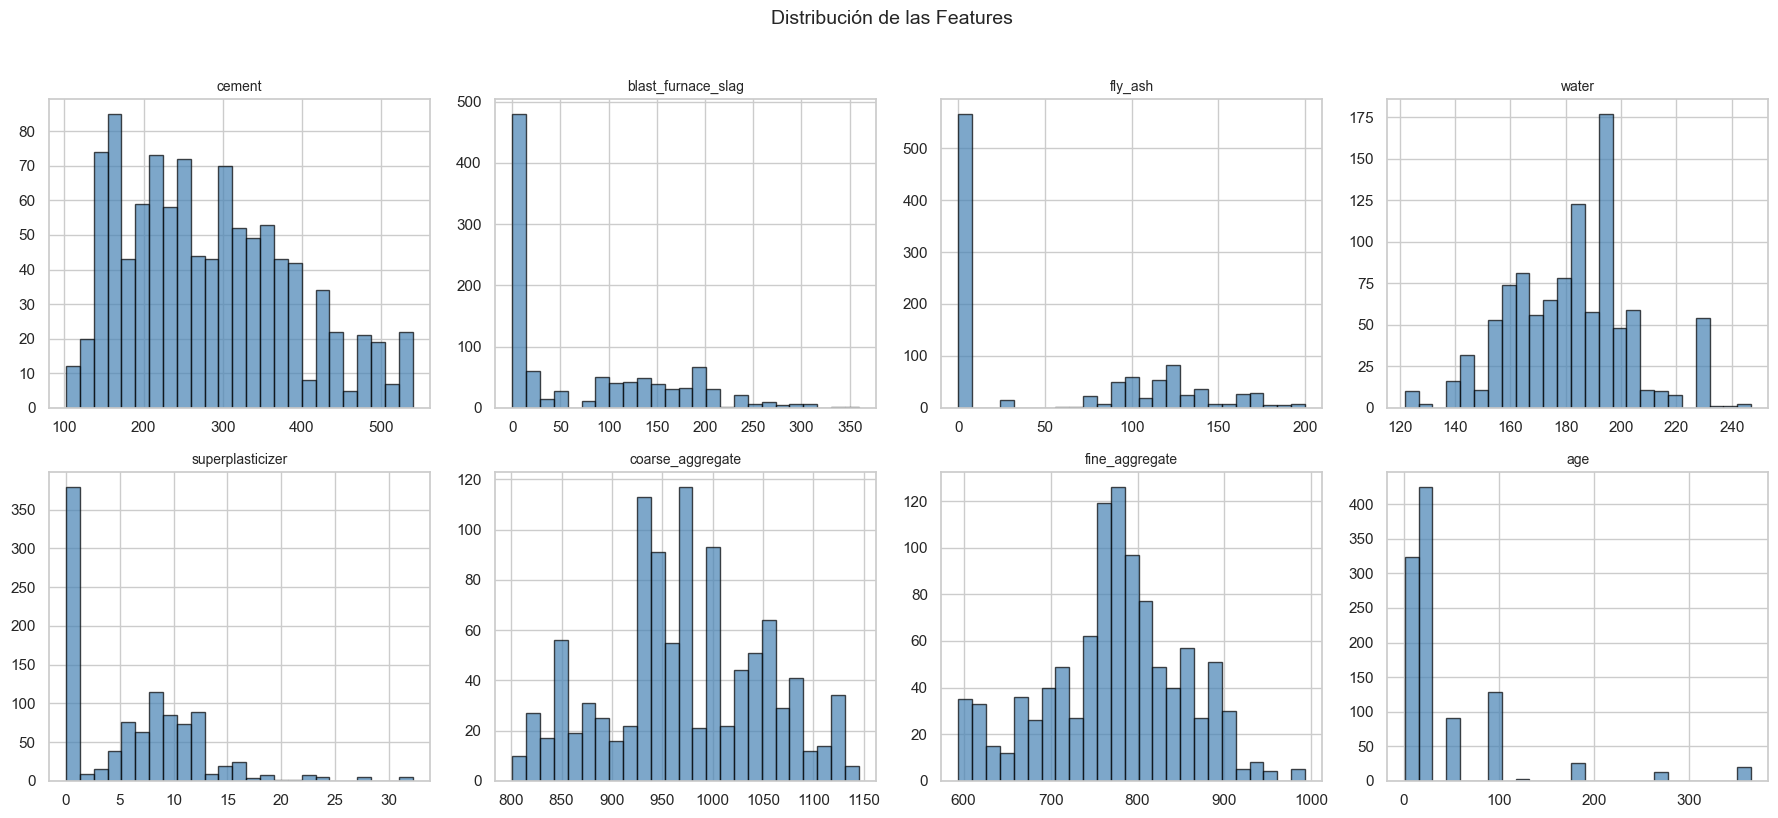

In [9]:
features = df.columns[:-1]  # Todas menos el target

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=25, edgecolor="black", alpha=0.7, color="steelblue")
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")

plt.suptitle("Distribución de las Features", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Matriz de correlación

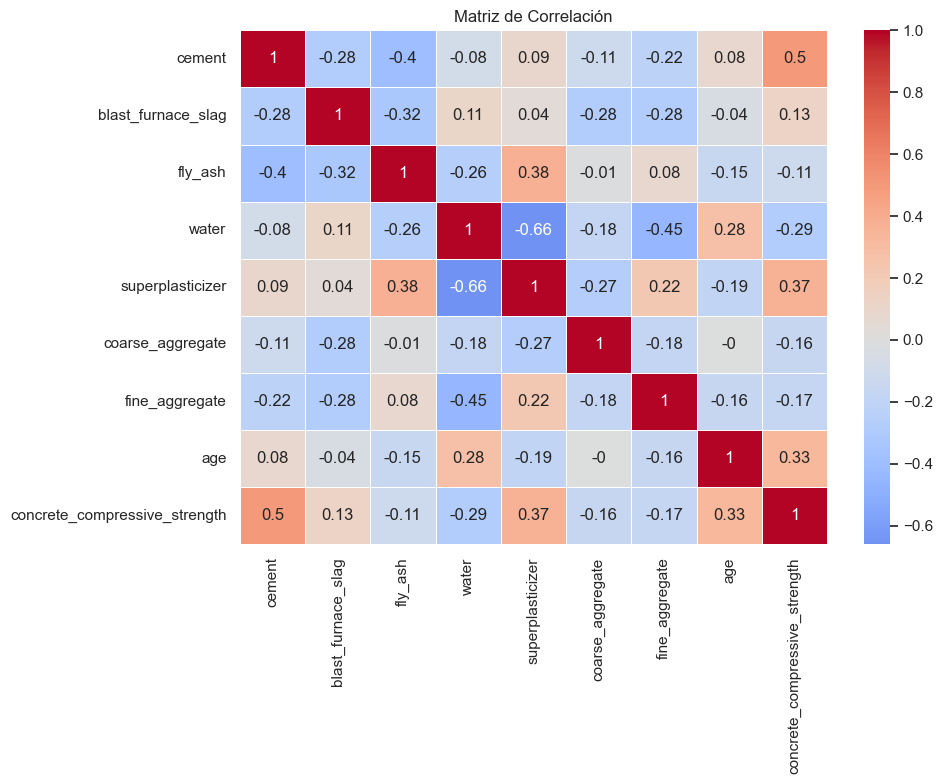

In [10]:
plt.figure(figsize=(10, 8))
correlation = df.corr().round(2)
sns.heatmap(correlation, annot=True, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Matriz de Correlación")
plt.tight_layout()
plt.show()

## 7. Relación de cada feature con el target

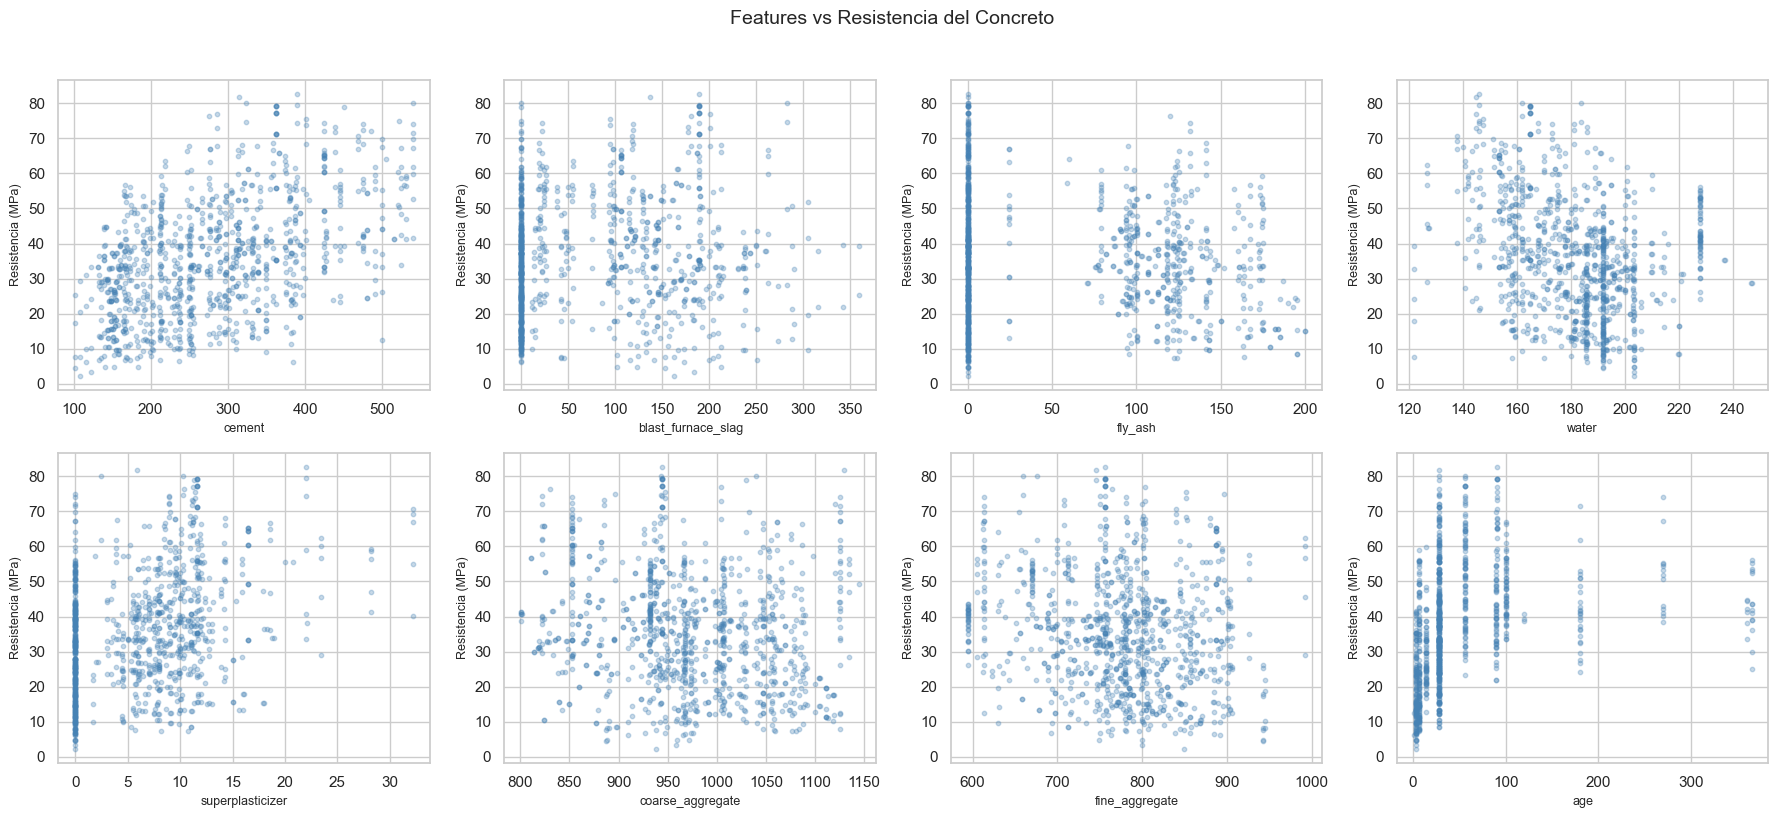

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].scatter(df[col], df["concrete_compressive_strength"],
                    alpha=0.3, s=10, color="steelblue")
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].set_ylabel("Resistencia (MPa)", fontsize=9)

plt.suptitle("Features vs Resistencia del Concreto", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Observaciones clave

Completa estas observaciones después de analizar los gráficos:

1. **Distribución del target**: _(describe la forma de la distribución)_
2. **Feature más correlacionada**: _(¿cuál tiene mayor correlación con el target?)_
3. **Valores nulos/duplicados**: _(¿encontraste algún problema de calidad?)_
4. **Escalas diferentes**: _(¿por qué necesitamos StandardScaler?)_

---

**Siguiente paso**: Ve al notebook `02_pipeline_y_entrenamiento` para construir
el Pipeline de Scikit-Learn y entrenar el modelo.